In [32]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import geopandas as gpd 
from pathlib import Path
import seamless_3dep as s3dep
import rioxarray as rxr
import py3dep
import pickle

In [10]:
sierras = gpd.read_file('../../data/misc/sierras_polygon_gmba.geojson')

In [33]:
atl06sr_gdf = pickle.load(open('../../data/icesat2/sierras_gdf_2018_2021_sa_processed_masked.pkl', 'rb'))

### Access 3DEP elevation data for plotting site fig

In [14]:
sierras_bbox = (-117.862654, 34.818611, -121.948903, 40.446988)

In [18]:
dem_200 = py3dep.get_map("DEM", sierras_bbox, resolution=200, geo_crs=4326, crs=4326)

<Axes: title={'center': 'spatial_ref = 0'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

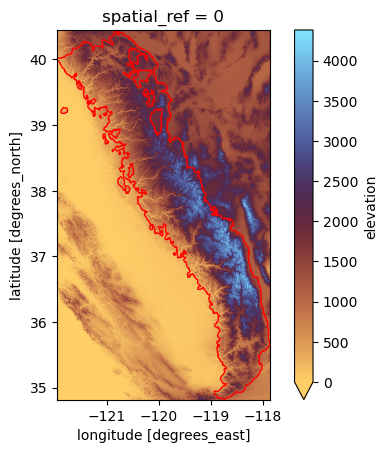

In [22]:
fig, ax = plt.subplots()

dem_200.plot(ax=ax, cmap='managua', vmin=0)
sierras.plot(ax=ax, facecolor="none", edgecolor="red")

In [25]:
sierras_200 = dem_200.rio.clip(sierras.geometry, sierras.crs, drop=True)

Text(0.5, 1.0, '')

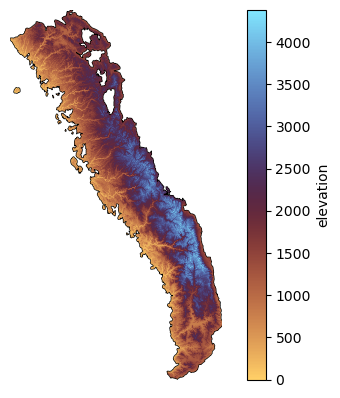

In [30]:
fig, ax = plt.subplots()

sierras_200.plot(ax=ax, cmap='managua', vmin=0, label='Elevation (m)')
sierras.plot(ax=ax, facecolor="none", edgecolor="k", linewidth=0.5)
ax.set_axis_off()
ax.set_title('')

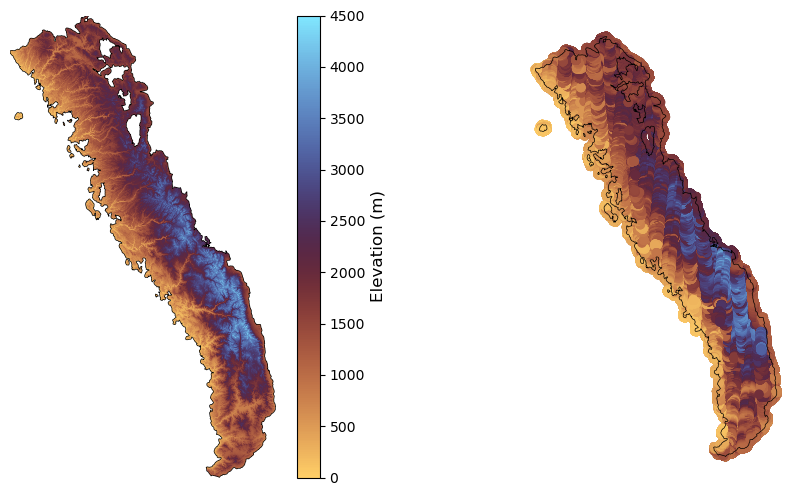

In [42]:
fig, ax = plt.subplots(1,2, figsize=(12,6))

cax = sierras_200.plot(ax=ax[0], cmap='managua', vmin=0, vmax=4500, add_colorbar=False)
sierras.plot(ax=ax[0], facecolor="none", edgecolor="k", linewidth=0.5)
ax[0].set_axis_off()
ax[0].set_title('')

atl06sr_gdf.plot(column='h_mean', ax=ax[1], cmap='managua', vmin=0, vmax=4500)
sierras.plot(ax=ax[1], facecolor="none", edgecolor="k", linewidth=0.5)
ax[1].set_axis_off()
ax[1].set_title('')

cbar = fig.colorbar(cax)
cbar.set_label('Elevation (m)', size=12)

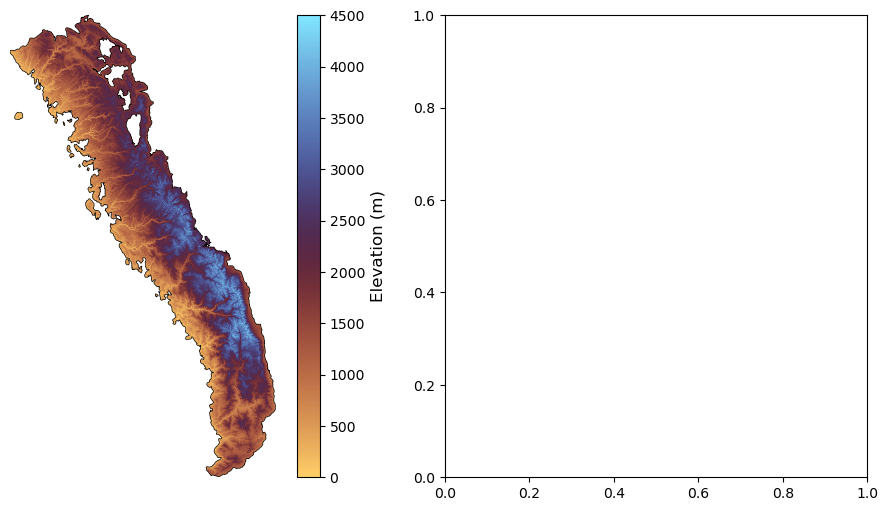

In [41]:
fig, ax = plt.subplots(1,2, figsize=(12,6))

cax = sierras_200.plot(ax=ax[0], cmap='managua', vmin=0, vmax=4500, add_colorbar=False)
sierras.plot(ax=ax[0], facecolor="none", edgecolor="k", linewidth=0.5)
ax[0].set_axis_off()
ax[0].set_title('')

# atl06sr_gdf.plot(column='h_mean', ax=ax[1], cmap='managua', vmin=0, vmax=4500)
# sierras.plot(ax=ax[1], facecolor="none", edgecolor="k", linewidth=0.5)
# ax[1].set_axis_off()
# ax[1].set_title('')

cbar = fig.colorbar(cax)
cbar.set_label('Elevation (m)', size=12)

### Reference map:

In [37]:
usa = gpd.read_file('../../data/misc/cb_2018_us_state_500k/cb_2018_us_state_500k.shp')

In [46]:
usa.crs

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

Text(0.5, 1.0, '')

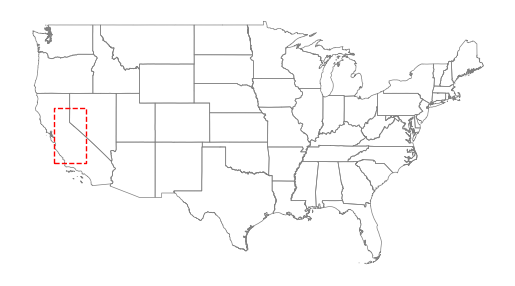

In [48]:
non_conus = ['Alaska', 'Hawaii', 'Puerto Rico', 
              'American Samoa', 'Commonwealth of the Northern Mariana Islands', 
              'Guam', 'United States Virgin Islands']

region = [  {"lon": -121.948903, "lat": 34.818611},
            {"lon": -117.862654, "lat": 34.818611},
            {"lon": -117.862654, "lat": 40.446988},
            {"lon": -121.948903, "lat": 40.446988},
            {"lon": -121.948903, "lat": 34.818611}  ]

region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]

fig, ax = plt.subplots()
#sierras.plot(ax=ax, facecolor="none", edgecolor="k", linewidth=1)
usa[~usa['NAME'].isin(non_conus)].to_crs('epsg:4326').plot(ax=ax, facecolor="none", edgecolor="grey", linewidth=0.5)
ax.plot(region_lon, region_lat, linewidth=1, color='r', linestyle='--')

ax.set_axis_off()
ax.set_title('')

(32.0, 43.0)

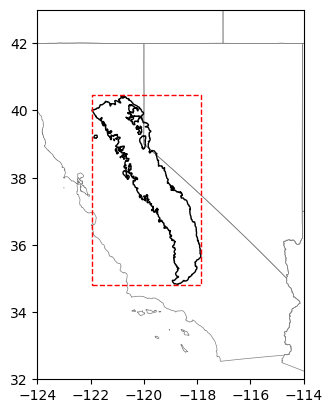

In [60]:
fig, ax = plt.subplots()
usa.plot(ax=ax, facecolor="none", edgecolor="grey", linewidth=0.5)
sierras.plot(ax=ax, facecolor="none", edgecolor="k", linewidth=1)
ax.plot(region_lon, region_lat, linewidth=1, color='r', linestyle='--')
ax.set_xlim(-124, -114)
ax.set_ylim(32, 43)

### Higher resolution, probably unnecessary:

In [16]:
dem = py3dep.get_map("DEM", sierras_bbox, resolution=60, geo_crs=4326, crs=4326)

<Axes: title={'center': 'spatial_ref = 0'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

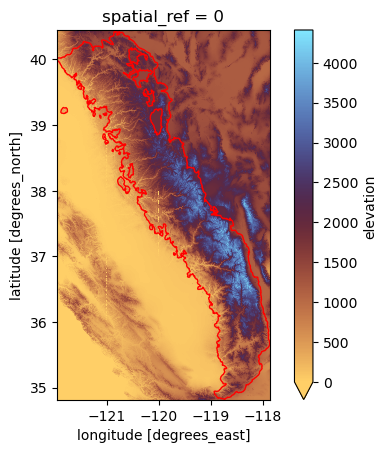

In [23]:
fig, ax = plt.subplots()

dem.plot(ax=ax, cmap='managua', vmin=0)
sierras.plot(ax=ax, facecolor="none", edgecolor="red")

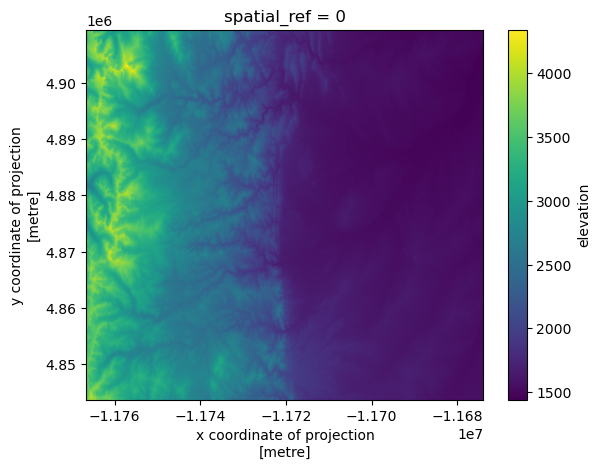

In [6]:
dem.plot()

In [ ]:
slope = py3dep.get_map("Slope Degrees", geom, resolution=30)
slope = py3dep.deg2mpm(slope)